In [99]:
import pandas as pd 
import numpy as np 

In [124]:
df=pd.read_csv("raw_data.csv")
df.head(5)

,timestamp,flow1,flow2,flow3,pressure,diff12,diff23,flow_ratio_12,flow_ratio_23,flag,zone,risk,reason
0,2026-04-03 00:09:20,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,NORMAL,LOW,Normal
1,2026-04-03 00:09:21,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,NORMAL,LOW,Normal
2,2026-04-03 00:09:22,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,NORMAL,LOW,Normal
3,2026-04-03 00:09:23,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,NORMAL,LOW,Normal
4,2026-04-03 00:09:24,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,NORMAL,LOW,Normal


## Relabeling Phase 

In [125]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [126]:
df['diff12'] = abs(df['flow1'] - df['flow2'])
df['diff23'] = abs(df['flow2'] - df['flow3'])

In [127]:
df['max_diff'] = df[['diff12', 'diff23']].max(axis=1)

In [128]:
def classify_leak(x):
    if x < 0.5:     # increased from 0.4
        return 0    # NORMAL
    else:
        return 1    # LEAK

In [129]:
df['leak_type'] = df['max_diff'].apply(classify_leak)

In [130]:
df['leak_label'] = df['leak_type'].apply(lambda x: 0 if x == 0 else 1)

In [131]:
df = df[~((df['flow1'] == 0) & (df['flow2'] == 0) & (df['flow3'] == 0))] # Remove useless 

In [132]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True) # shuffle 

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      315 non-null    datetime64[ns]
 1   flow1          315 non-null    float64       
 2   flow2          315 non-null    float64       
 3   flow3          315 non-null    float64       
 4   pressure       315 non-null    float64       
 5   diff12         315 non-null    float64       
 6   diff23         315 non-null    float64       
 7   flow_ratio_12  315 non-null    float64       
 8   flow_ratio_23  315 non-null    float64       
 9   flag           315 non-null    int64         
 10  zone           315 non-null    object        
 11  risk           315 non-null    object        
 12  reason         315 non-null    object        
 13  max_diff       315 non-null    float64       
 14  leak_type      315 non-null    int64         
 15  leak_label     315 non-

In [134]:
df["leak_label"].value_counts()

1    300
0     15
Name: leak_label, dtype: int64

## Data Visualization

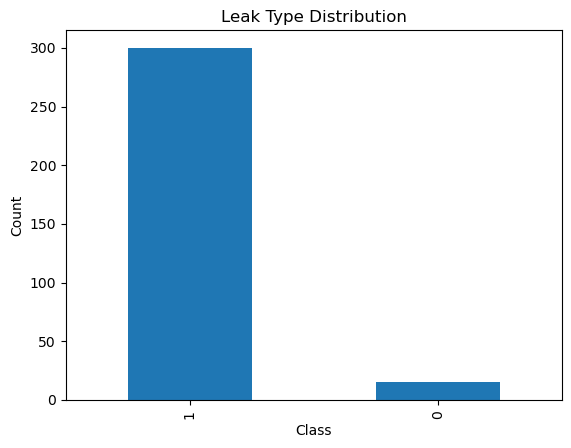

In [135]:
import matplotlib.pyplot as plt

df['leak_label'].value_counts().plot(kind='bar')
plt.title("Leak Type Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

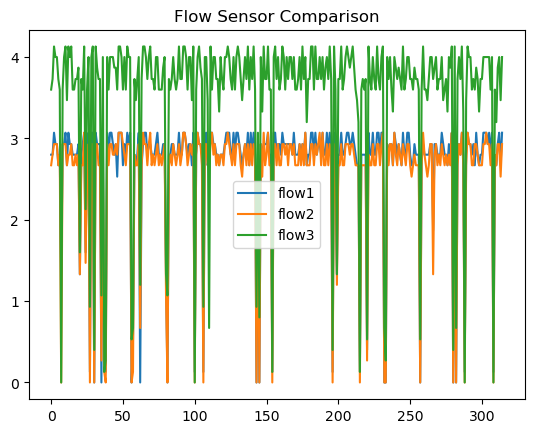

In [136]:
plt.figure()
plt.plot(df['flow1'], label='flow1')
plt.plot(df['flow2'], label='flow2')
plt.plot(df['flow3'], label='flow3')
plt.legend()
plt.title("Flow Sensor Comparison")
plt.show()

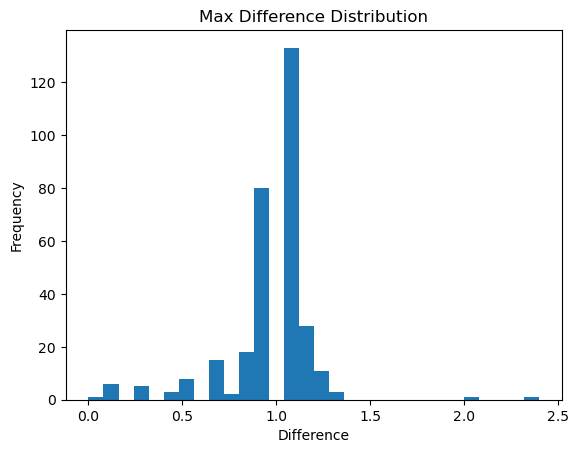

In [137]:
plt.figure()
plt.hist(df['max_diff'], bins=30)
plt.title("Max Difference Distribution")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.show()

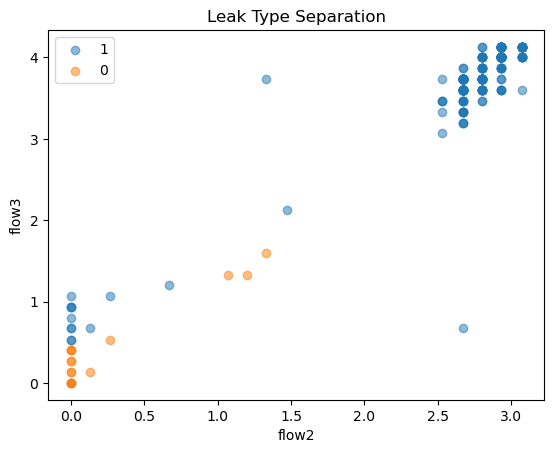

In [138]:
plt.figure()

for label in df['leak_type'].unique():
    subset = df[df['leak_type'] == label]
    plt.scatter(subset['flow2'], subset['flow3'], label=label, alpha=0.5)

plt.legend()
plt.xlabel("flow2")
plt.ylabel("flow3")
plt.title("Leak Type Separation")
plt.show()

## Model Trainer 

In [139]:
from imblearn.over_sampling import SMOTE

features = [
    'flow1', 'flow2', 'flow3', 'pressure',
    'diff12', 'diff23',
    'flow_ratio_12', 'flow_ratio_23'
]

X = df[features]
y = df['leak_label']

sm = SMOTE(
    sampling_strategy=0.5,  # not full balance (important!)
    random_state=42
)

X_res, y_res = sm.fit_resample(X, y)

In [144]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [145]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [140]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    random_state=42
)

In [146]:
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 3  0]
 [ 0 60]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        60

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63

